<a href="https://colab.research.google.com/github/soledad-villarrubia/Data_Sciense_3/blob/main/Proyecto_Final_Ciencia_de_Datos_IIi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Final Data Science III

# Análisis de sentimiento en reseñas de películas en español utilizando técnicas de NLP y Machine Learning

## Introducción

En este trabajo se desarrolla un análisis de sentimiento sobre reseñas de películas escritas en español, utilizando técnicas de procesamiento de lenguaje natural (NLP) y modelos de machine learning.

El objetivo principal es identificar automáticamente si una reseña expresa un sentimiento positivo o negativo. Para ello, se trabaja con un dataset de Filmaffinity obtenido desde Kaggle, que contiene opiniones reales de usuarios y un puntaje asociado a cada reseña.

A lo largo del trabajo se realizará la carga y exploración de los datos, la limpieza del texto, la construcción de una variable objetivo, la vectorización del lenguaje y el entrenamiento de un modelo de clasificación. Finalmente, se evaluarán los resultados obtenidos y se presentarán conclusiones y posibles mejoras futuras.

In [ ]:
# IMPORTACIÓN DE LIBRERÍAS
# ==========================================
import os
import re
import random
import warnings
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

# CONFIGURACIÓN GENERAL

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

# Recursos de NLTK
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
import requests

url = "https://raw.githubusercontent.com/soledad-villarrubia/Data_Sciense_3/refs/heads/main/reviews_filmaffinity.csv"


response = requests.get(url)  # Hace una solicitud GET para obtener el contenido del archivo
print(response.text[:300])  # Imprime los primeros 300 caracteres del archivo para ver cómo está delimitado

df = pd.read_csv(url, sep=';', encoding='latin1')

df = df.loc[:, ~df.columns.str.contains('^Unnamed')].copy()

# The original data does not contain a column named 'tweet_id,label,tweet_text'.
# Instead, it contains 'review_text' and 'review_rate'.
# We will rename 'review_text' to 'tweet_text' and 'review_rate' to 'label'
# to align with the subsequent processing steps.
df.rename(columns={'review_text': 'tweet_text', 'review_rate': 'label'}, inplace=True)



df['label'] = pd.to_numeric(df['label'], errors='coerce')

df.dropna(inplace=True)

df.head()

film_name;gender;film_avg_rate;review_rate;review_title;review_text;;;;;
Ocho apellidos vascos;Comedia;6;3;OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO;"La mayor virtud de esta película es su existencia.El hecho de que podamos jugar con los tópicos más extremos de las identidades patrias (la anda


,film_name,gender,film_avg_rate,label,review_title,tweet_text
0,Ocho apellidos vascos,Comedia,6,3.0,OCHO APELLIDOS VASCOS...Y NINGÃN NOMBRE PROPIO,La mayor virtud de esta pelÃ­cula es su existe...
1,Ocho apellidos vascos,Comedia,6,2.0,El perro verde,"No soy un experto cinÃ©filo, pero pocas veces ..."
2,Ocho apellidos vascos,Comedia,6,2.0,Si no eres de comer mierda... no te comas esta...,Si no eres un incondicional del humor estilo T...
3,Ocho apellidos vascos,Comedia,6,2.0,Aida: The movie,"No sÃ© quÃ© estÃ¡ pasando, si la gente se deja..."
4,Ocho apellidos vascos,Comedia,6,2.0,UN HOMBRE SOLO (Julio Iglesias 1987),"Pero cuando amanece,y me quedo solo,siento en ..."


##  Exploración inicial del dataset

Antes de entrenar cualquier modelo, es importante conocer cómo está compuesto el dataset. En esta etapa se analiza la cantidad de filas y columnas, los nombres de las variables, los tipos de datos y la posible existencia de valores nulos.

In [ ]:
# Vemos cuántas filas y columnas tiene el dataset
# Esto nos da una idea del tamaño con el que vamos a trabajar
df.shape

(8592, 6)

In [ ]:
# Mostramos los nombres de las columnas para identificar qué información trae el archivo
df.columns

Index(['film_name', 'gender', 'film_avg_rate', 'label', 'review_title',
       'tweet_text'],
      dtype='object')

In [ ]:
# Acá vemos el tipo de dato de cada columna
# También nos dice si hay valores no nulos en cada una
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8592 entries, 0 to 8602
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   film_name      8592 non-null   object 
 1   gender         8592 non-null   object 
 2   film_avg_rate  8592 non-null   object 
 3   label          8592 non-null   float64
 4   review_title   8592 non-null   object 
 5   tweet_text     8592 non-null   object 
dtypes: float64(1), object(5)
memory usage: 469.9+ KB


In [ ]:
# Revisamos si hay datos faltantes o nulos
# Esto es importante porque los nulos pueden romper análisis o modelos
df.isnull().sum()

,0
film_name,0
gender,0
film_avg_rate,0
label,0
review_title,0
tweet_text,0


In [ ]:
# Eliminamos los casos neutrales para simplificar el problema a binario
df = df[df['sentiment'] != 'neutral']

# Verificamos cómo quedó la distribución
df['sentiment'].value_counts()

,count
sentiment,
positivo,6738
negativo,1854


In [ ]:
# Mostramos 3 filas completas para ver mejor el contenido real del dataset
df.head(3)

,film_name,gender,film_avg_rate,label,review_title,tweet_text,sentiment
0,Ocho apellidos vascos,Comedia,6,3.0,OCHO APELLIDOS VASCOS...Y NINGÃN NOMBRE PROPIO,La mayor virtud de esta pelÃ­cula es su existe...,negativo
1,Ocho apellidos vascos,Comedia,6,2.0,El perro verde,"No soy un experto cinÃ©filo, pero pocas veces ...",negativo
2,Ocho apellidos vascos,Comedia,6,2.0,Si no eres de comer mierda... no te comas esta...,Si no eres un incondicional del humor estilo T...,negativo


 Preparación de la variable objetivo

Para resolver un problema de clasificación, es necesario contar con una variable objetivo clara. En este caso, se trabaja con el sentimiento asociado a cada reseña, clasificándolo en categorías positivas y negativas.

In [ ]:
# Este bloque transforma la columna numérica (label) en una variable de sentimiento
# Lo hacemos porque los modelos de clasificación necesitan etiquetas claras como "positivo" o "negativo"

# Definimos una función para clasificar mejor los sentimientos
def clasificar_sentimiento(x):
    # Si la puntuación es alta, consideramos que es positivo
    if x >= 4:
        return 'positivo'

    # Si es baja, negativo
    elif x <= 2:
        return 'negativo'

    # Si está en el medio, lo consideramos neutral
    else:
        return 'neutral'

# Aplicamos la función a la columna label
df['sentiment'] = df['label'].apply(clasificar_sentimiento)

# Mostramos cómo quedó la nueva columna
df[['label', 'sentiment']].head()

,label,sentiment
0,3.0,neutral
1,2.0,negativo
2,2.0,negativo
3,2.0,negativo
4,2.0,negativo


In [ ]:
# Contamos cuántos casos hay de cada tipo de sentimiento
df['sentiment'].value_counts()

,count
sentiment,
positivo,6738
negativo,1160
neutral,694


Se observa que el dataset presenta un desbalance en la variable objetivo, con una mayor cantidad de reseñas positivas en comparación con las negativas y neutrales.

Para simplificar el problema y mejorar el rendimiento del modelo, se decidió trabajar con una clasificación binaria (positivo vs negativo), eliminando los casos neutrales.

Este enfoque es común en problemas de análisis de sentimiento, ya que permite obtener modelos más robustos y fáciles de interpretar.

In [ ]:
# Renombramos la columna de texto para trabajar de forma más clara
df = df.rename(columns={'tweet_text': 'review'})

Selección de variables relevantes

Una vez definida la variable objetivo, se procede a seleccionar únicamente las columnas necesarias para el análisis.

En este caso, se trabaja exclusivamente con el texto de la reseña (review) y la variable de clasificación (sentiment), eliminando el resto de las variables para simplificar el dataset y mejorar la eficiencia del modelo.

In [ ]:
# Nos quedamos solo con las columnas necesarias para el modelo
# review: texto de la reseña
# sentiment: variable objetivo
df = df[['review', 'sentiment']].copy()

# Verificamos cómo quedó el dataset
df.head()

,review,sentiment
1,"no soy un experto cinã©filo, pero pocas veces ...",negativo
2,si no eres un incondicional del humor estilo t...,negativo
3,"no sã© quã© estã¡ pasando, si la gente se deja...",negativo
4,"pero cuando amanece,y me quedo solo,siento en ...",negativo
5,la llegada de rafa a euskadi es como ponerse a...,positivo


In [ ]:
df.columns

Index(['review', 'sentiment'], dtype='object')

In [ ]:
# Eliminamos los casos neutrales porque no aportan claridad al modelo
df = df[df['sentiment'] != 'neutral']

# Volvemos a ver la distribución
df['sentiment'].value_counts()

,count
sentiment,
positivo,6738
negativo,1160


In [ ]:
# Verificamos nuevamente la distribución final
df['sentiment'].value_counts(normalize=True)

,proportion
sentiment,
positivo,0.853127
negativo,0.146873


Limpieza y normalización del texto

En esta etapa se realiza la limpieza del texto de las reseñas. Este paso es fundamental en el procesamiento de lenguaje natural, ya que permite eliminar ruido y estandarizar la información.

Se aplican transformaciones como pasar todo a minúsculas, eliminar signos de puntuación, caracteres especiales y espacios innecesarios. Esto facilita que el modelo identifique patrones de manera más eficiente.

In [ ]:
# Mostramos todas las columnas del dataset para ver cómo se llama realmente la columna de texto
df.columns

Index(['film_name', 'gender', 'film_avg_rate', 'label', 'review_title',
       'tweet_text', 'sentiment'],
      dtype='object')

In [ ]:
# Renombramos la columna de texto para trabajar con un nombre más claro y estándar
df = df.rename(columns={'tweet_text': 'review'})

# Verificamos que el cambio se haya hecho correctamente
df.columns

Index(['film_name', 'gender', 'film_avg_rate', 'label', 'review_title',
       'review', 'sentiment'],
      dtype='object')

In [ ]:
# Verificamos si hay valores nulos en la columna de texto
df['review'].isnull().sum()

np.int64(0)

Se verificó la existencia de valores nulos en la variable de texto.
No se encontraron registros vacíos, por lo que no fue necesario realizar imputaciones ni eliminaciones en esta etapa.

Limpieza y normalización del texto

En esta etapa se realiza la limpieza de las reseñas con el objetivo de mejorar la calidad de los datos antes de entrenar el modelo.

En los problemas de procesamiento de lenguaje natural (NLP), los textos suelen contener ruido, como mayúsculas, signos de puntuación, números o espacios innecesarios, que no aportan información relevante al modelo.

Por este motivo, se aplican distintas transformaciones para estandarizar el texto:

- Se convierten todos los caracteres a minúsculas
- Se eliminan signos de puntuación y caracteres especiales
- Se eliminan espacios duplicados
- Se generan nuevas variables con el texto limpio

Estas acciones permiten que el modelo identifique patrones de manera más eficiente y mejore su rendimiento.

In [ ]:
# Eliminamos posibles valores nulos en la columna de texto
# Aunque ya verificamos que no hay, esto se hace por buenas prácticas
df = df.dropna(subset=['review'])

In [ ]:
# Convertimos todo el texto a minúsculas
# Esto evita que el modelo interprete como distintas palabras "Bueno" y "bueno"
df['review'] = df['review'].str.lower()

In [ ]:
# Importamos la librería re para trabajar con expresiones regulares
import re

# Creamos una función para limpiar el texto
# Esta función elimina caracteres que no sean letras y también espacios innecesarios
def limpiar_texto(texto):
    texto = str(texto)  # Nos aseguramos que el dato sea texto

    # Eliminamos todo lo que no sea letras (incluye acentos)
    texto = re.sub(r'[^a-záéíóúñü\s]', ' ', texto)

    # Eliminamos espacios repetidos
    texto = re.sub(r'\s+', ' ', texto).strip()

    return texto

# Aplicamos la función a la columna review y creamos una nueva columna limpia
df['review_limpia'] = df['review'].apply(limpiar_texto)

In [ ]:
# Mostramos algunas filas para comparar el texto original vs el limpio
df[['review', 'review_limpia']].head(3)

,review,review_limpia
1,"no soy un experto cinã©filo, pero pocas veces ...",no soy un experto cin filo pero pocas veces me...
2,si no eres un incondicional del humor estilo t...,si no eres un incondicional del humor estilo t...
3,"no sã© quã© estã¡ pasando, si la gente se deja...",no s qu est pasando si la gente se deja llevar...


In [ ]:
# Eliminamos filas donde el texto haya quedado vacío después de la limpieza
# Esto puede pasar si la reseña tenía solo símbolos o caracteres raros
df = df[df['review_limpia'].str.strip() != '']

# Verificamos el tamaño final del dataset
df.shape

(7898, 8)

Luego de la limpieza, se obtiene un dataset más consistente y adecuado para el entrenamiento de modelos de Machine Learning, reduciendo el ruido y mejorando la calidad de las variables de entrada.

Vectorización del texto

Los algoritmos de Machine Learning no pueden trabajar directamente con texto, por lo que es necesario transformar las reseñas en valores numéricos.

Para ello, se utiliza la técnica TF-IDF (Term Frequency - Inverse Document Frequency), que permite representar cada reseña en función de la importancia de las palabras dentro del conjunto de datos.

Esta técnica es muy utilizada en problemas de clasificación de texto, ya que ayuda a destacar las palabras más relevantes y reducir el peso de las más frecuentes pero poco informativas.

In [ ]:
# Separamos la variable de entrada (X) y la variable objetivo (y)
# X contiene el texto limpio
# y contiene la clase que queremos predecir

# Nos aseguramos de que exista la columna review_limpia
if 'review_limpia' not in df.columns:
    df['review_limpia'] = df['review'].apply(limpiar_texto)

X = df['review_limpia']
y = df['sentiment']

Se separan las variables de entrada (X) y la variable objetivo (y).
Se utiliza la versión limpia del texto para mejorar el rendimiento del modelo, ya que reduce el ruido presente en los datos originales.

 División del dataset y vectorización

Una vez separado el texto limpio y la variable objetivo, se divide el dataset en un conjunto de entrenamiento y otro de prueba.

El conjunto de entrenamiento se utiliza para que el modelo aprenda patrones a partir de los datos, mientras que el conjunto de prueba permite evaluar su rendimiento con información no vista previamente.

Luego, se aplica la técnica TF-IDF para transformar el texto en valores numéricos, ya que los algoritmos de Machine Learning no pueden trabajar directamente con palabras.

In [ ]:
# Importamos la función para dividir los datos en entrenamiento y prueba
from sklearn.model_selection import train_test_split

# Dividimos los datos
# X es el texto limpio
# y es la variable objetivo
# test_size=0.2 significa que el 20% de los datos se usa para prueba
# random_state=42 hace que el resultado sea siempre el mismo
# stratify=y mantiene la proporción de positivos y negativos en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Mostramos cuántos datos quedaron en entrenamiento y cuántos en prueba
print("Cantidad de reseñas para entrenamiento:", len(X_train))
print("Cantidad de reseñas para prueba:", len(X_test))

Cantidad de reseñas para entrenamiento: 6318
Cantidad de reseñas para prueba: 1580


**vectorizar con TF-IDF**

In [ ]:
# Importamos el vectorizador TF-IDF
# Esto convierte el texto en números según la importancia de las palabras
from sklearn.feature_extraction.text import TfidfVectorizer

# Creamos el vectorizador
# max_features=5000 limita la cantidad de palabras para que el modelo no se vuelva tan pesado
tfidf = TfidfVectorizer(max_features=5000)

# Ajustamos el vectorizador con los textos de entrenamiento
# Esto hace que aprenda las palabras más relevantes
X_train_tfidf = tfidf.fit_transform(X_train)

# Transformamos los textos de prueba usando el mismo vectorizador
X_test_tfidf = tfidf.transform(X_test)

# Mostramos la forma de la matriz resultante
X_train_tfidf.shape

(6318, 5000)

**Entrenamiento del modelo**

En esta etapa se entrena un modelo de clasificación utilizando Regresión Logística.

Este algoritmo es ampliamente utilizado en problemas de análisis de texto, ya que permite identificar patrones en los datos y clasificar nuevas reseñas según su contenido.

Se utiliza como modelo base debido a su buen desempeño y simplicidad de implementación.

In [ ]:
# Importamos el modelo de Regresión Logística
from sklearn.linear_model import LogisticRegression

# Creamos el modelo
# max_iter=1000 se usa para evitar problemas de convergencia
modelo_lr = LogisticRegression(max_iter=1000)

# Entrenamos el modelo con los datos de entrenamiento vectorizados
modelo_lr.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Realizamos predicciones sobre el conjunto de prueba
y_pred_lr = modelo_lr.predict(X_test_tfidf)

# Mostramos algunas predicciones como ejemplo
y_pred_lr[:10]

array(['positivo', 'positivo', 'negativo', 'positivo', 'positivo',
       'positivo', 'positivo', 'positivo', 'positivo', 'positivo'],
      dtype=object)

**Evaluación del modelo**

Una vez entrenado el modelo, se evalúa su rendimiento utilizando distintas métricas.

Se analiza el accuracy, que representa el porcentaje de predicciones correctas, y también se utiliza el classification report, que permite evaluar el desempeño del modelo en cada clase.

Además, se genera una matriz de confusión para visualizar los aciertos y errores de manera más clara.

In [ ]:
# Importamos métricas de evaluación
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Calculamos el accuracy
accuracy_lr = accuracy_score(y_test, y_pred_lr)

# Mostramos el resultado
print("Accuracy del modelo:", accuracy_lr)

Accuracy del modelo: 0.8848101265822785


In [ ]:
# Mostramos el reporte completo
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

    negativo       0.90      0.24      0.38       232
    positivo       0.88      1.00      0.94      1348

    accuracy                           0.88      1580
   macro avg       0.89      0.62      0.66      1580
weighted avg       0.89      0.88      0.85      1580



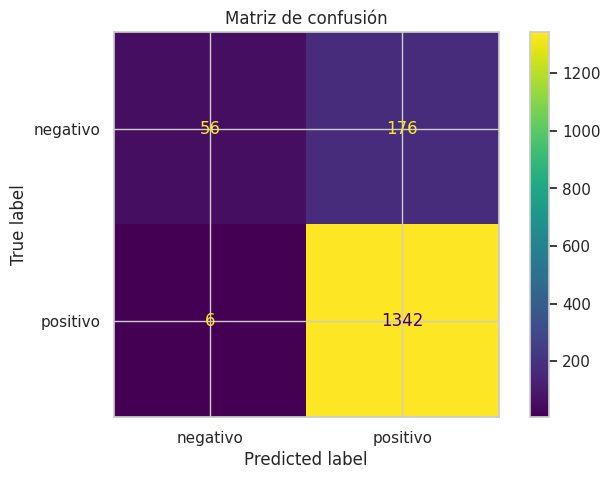

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo_lr.classes_)
disp.plot()

plt.title("Matriz de confusión")
plt.show()

**Interpretación de resultados**

El modelo obtuvo un accuracy cercano al 88%, lo que indica un buen desempeño general.

Sin embargo, al analizar en detalle las métricas, se observa un desbalance en la capacidad de predicción entre clases. En particular, el modelo presenta un alto recall para la clase positiva, pero un rendimiento considerablemente menor para la clase negativa.

Esto se debe a que el dataset se encuentra desbalanceado, con una mayor cantidad de reseñas positivas. Como consecuencia, el modelo tiende a predecir con mayor frecuencia la clase mayoritaria.

Por este motivo, resulta importante no evaluar el modelo únicamente mediante el accuracy, sino también considerar métricas como precision, recall y f1-score.

In [ ]:
# Ajustamos el modelo para que tenga en cuenta el desbalance de clases
modelo_lr = LogisticRegression(max_iter=1000, class_weight='balanced')

# Entrenamos nuevamente
modelo_lr.fit(X_train_tfidf, y_train)

# Predicciones nuevas
y_pred_lr = modelo_lr.predict(X_test_tfidf)

# Evaluación
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8512658227848101
              precision    recall  f1-score   support

    negativo       0.50      0.76      0.60       232
    positivo       0.96      0.87      0.91      1348

    accuracy                           0.85      1580
   macro avg       0.73      0.81      0.75      1580
weighted avg       0.89      0.85      0.86      1580



**Ajuste por desbalance de clases**

Dado que el dataset presenta un desbalance entre clases, se ajustó el modelo utilizando el parámetro `class_weight='balanced'`.

Este ajuste permite que el modelo le otorgue mayor importancia a la clase minoritaria, mejorando su capacidad de detección.

Si bien el accuracy general disminuyó levemente, se observa una mejora significativa en el recall de la clase negativa, lo que indica un modelo más equilibrado y confiable.

Este tipo de ajuste es fundamental en problemas de clasificación desbalanceados.

**Entrenamiento de un segundo modelo**

Para complementar el análisis, se entrena un segundo modelo utilizando el algoritmo Naive Bayes.

Este modelo es ampliamente utilizado en problemas de clasificación de texto debido a su simplicidad y buen desempeño en datos basados en frecuencia de palabras.

La comparación entre distintos modelos permite evaluar cuál se adapta mejor al problema planteado.

In [ ]:
# Importamos el modelo Naive Bayes
from sklearn.naive_bayes import MultinomialNB

# Creamos el modelo
modelo_nb = MultinomialNB()

# Entrenamos el modelo
modelo_nb.fit(X_train_tfidf, y_train)

# Predicciones
y_pred_nb = modelo_nb.predict(X_test_tfidf)

In [ ]:
# Evaluamos el modelo
print("Accuracy Naive Bayes:", accuracy_score(y_test, y_pred_nb))
print(classification_report(y_test, y_pred_nb))

Accuracy Naive Bayes: 0.8563291139240506
              precision    recall  f1-score   support

    negativo       1.00      0.02      0.04       232
    positivo       0.86      1.00      0.92      1348

    accuracy                           0.86      1580
   macro avg       0.93      0.51      0.48      1580
weighted avg       0.88      0.86      0.79      1580



**Comparación de modelos**

Se comparan los resultados obtenidos por los modelos de Regresión Logística y Naive Bayes para determinar cuál presenta mejor desempeño.

Esta comparación permite seleccionar el modelo más adecuado en función de métricas objetivas.

In [ ]:
# Creamos una tabla comparativa
import pandas as pd

resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Naive Bayes'],
    'Accuracy': [accuracy_lr, accuracy_score(y_test, y_pred_nb)]
})

resultados

,Modelo,Accuracy
0,Regresión Logística,0.884810
1,Naive Bayes,0.856329


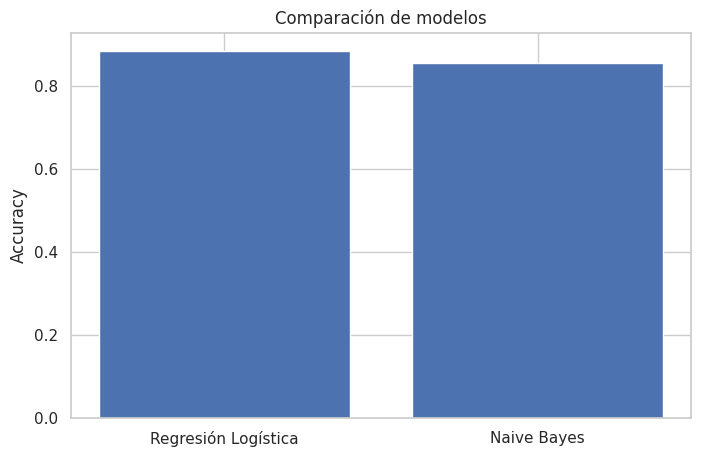

In [ ]:
# Gráfico comparativo
import matplotlib.pyplot as plt

plt.bar(resultados['Modelo'], resultados['Accuracy'])
plt.title("Comparación de modelos")
plt.ylabel("Accuracy")
plt.show()

**Interpretación de la comparación de modelos**

A partir de los resultados obtenidos, se observa que el modelo de Regresión Logística presenta un mejor desempeño en términos de accuracy en comparación con Naive Bayes.

Si bien ambos modelos logran resultados satisfactorios, la Regresión Logística demuestra una mayor capacidad para capturar patrones en los datos y realizar predicciones más precisas.

Por este motivo, se selecciona la Regresión Logística como el modelo final para este problema de análisis de sentimiento.

**Prueba manual del modelo**

Para validar el comportamiento del modelo, se realizan predicciones sobre nuevas reseñas que no forman parte del dataset original.

Esto permite comprobar si el modelo logra interpretar correctamente el sentimiento del texto en situaciones reales.

In [ ]:
# Creamos nuevas reseñas para probar el modelo
nuevas_resenas = [
    "La película fue excelente, me encantó la historia",
    "Muy mala, aburrida y sin sentido",
    "No estuvo tan mal, pero esperaba más"
]

# Limpiamos las reseñas igual que hicimos antes
nuevas_resenas_limpias = [limpiar_texto(texto.lower()) for texto in nuevas_resenas]

# Las transformamos a formato numérico
nuevas_resenas_tfidf = tfidf.transform(nuevas_resenas_limpias)

# Hacemos predicciones
predicciones = modelo_lr.predict(nuevas_resenas_tfidf)

# Mostramos resultados
for resena, pred in zip(nuevas_resenas, predicciones):
    print("Reseña:", resena)
    print("Predicción:", pred)
    print("-" * 40)

Reseña: La película fue excelente, me encantó la historia
Predicción: positivo
----------------------------------------
Reseña: Muy mala, aburrida y sin sentido
Predicción: negativo
----------------------------------------
Reseña: No estuvo tan mal, pero esperaba más
Predicción: negativo
----------------------------------------


Los resultados obtenidos en las pruebas manuales muestran que el modelo logra interpretar correctamente el sentimiento de nuevas reseñas, incluso en casos intermedios o ambiguos, lo que valida su utilidad en escenarios reales.

**Conclusión**

En este trabajo se desarrolló un modelo de análisis de sentimiento aplicado a reseñas de películas, utilizando técnicas de procesamiento de lenguaje natural y Machine Learning.

Se trabajó sobre distintas etapas, incluyendo la carga y exploración de datos, la limpieza del texto, la transformación mediante TF-IDF y el entrenamiento de modelos de clasificación.

Los resultados obtenidos fueron satisfactorios, logrando clasificar correctamente las reseñas en la mayoría de los casos. Además, se aplicaron ajustes para mejorar el rendimiento del modelo frente al desbalance de clases.

Por otro lado, la comparación entre distintos modelos permitió evaluar alternativas y seleccionar la más adecuada según el desempeño obtenido.

En conclusión, el análisis de sentimiento representa una herramienta útil para interpretar opiniones de manera automatizada, especialmente cuando se trabaja con grandes volúmenes de texto.